In [1]:
# Hiring Trends Analysis
# recruiting-funnel-analytics | github.com/harthikrm
# Analyzes monthly application volume, seasonal patterns,
# time-to-hire by quarter, and offer acceptance rate trends

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Blues_d")


/Users/harthikmallichetty/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
apps = pd.read_csv('../data/raw/applications.csv')
hires = pd.read_csv('../data/raw/hires.csv')
offers = pd.read_csv('../data/raw/offers.csv')
reqs = pd.read_csv('../data/raw/requisitions.csv')
stages = pd.read_csv('../data/raw/stage_events.csv')
candidates = pd.read_csv('../data/raw/candidates.csv')

apps['applied_at'] = pd.to_datetime(apps['applied_at'])
hires['hired_at'] = pd.to_datetime(hires['hired_at'])
offers['offered_at'] = pd.to_datetime(offers['offered_at'])
reqs['opened_at'] = pd.to_datetime(reqs['opened_at'])
reqs['closed_at'] = pd.to_datetime(reqs['closed_at'])
stages['event_ts'] = pd.to_datetime(stages['event_ts'])

print(f"Applications: {len(apps):,}")
print(f"Hires: {len(hires):,}")
print(f"Offers: {len(offers):,}")
print(f"Requisitions: {len(reqs):,}")
print(f"Stage Events: {len(stages):,}")


Applications: 5,212
Hires: 210
Offers: 280
Requisitions: 180
Stage Events: 16,896


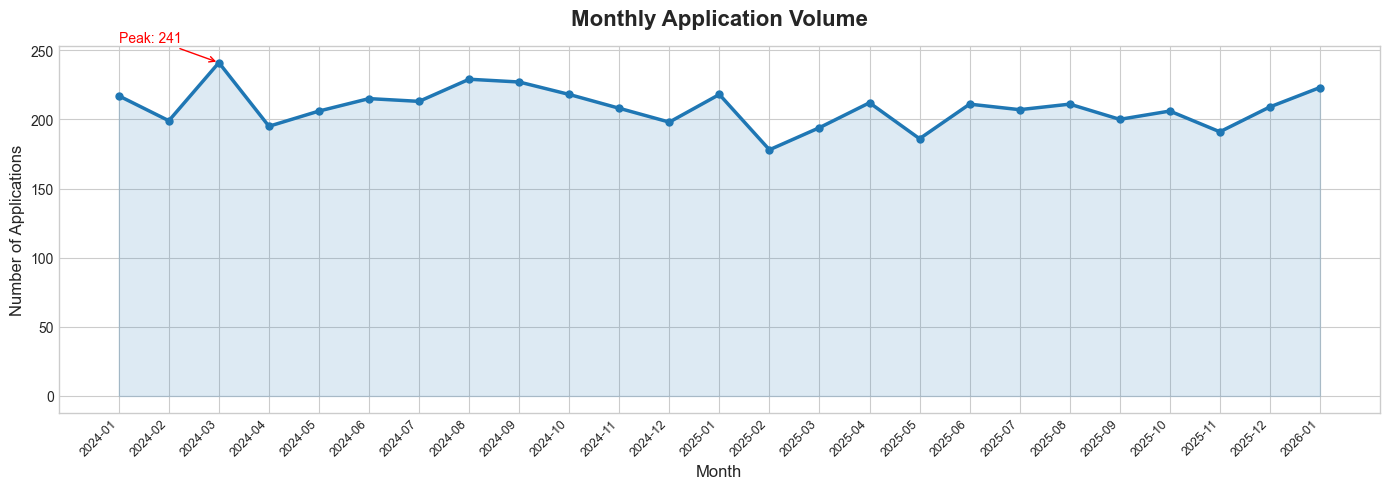

Saved: 01_monthly_application_volume.png


In [3]:
apps['year_month'] = apps['applied_at'].dt.to_period('M')
monthly = apps.groupby('year_month').size().reset_index(name='applications')
monthly['year_month_str'] = monthly['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['year_month_str'], monthly['applications'],
        marker='o', linewidth=2.5, color='#1f77b4', markersize=5)
ax.fill_between(monthly['year_month_str'], monthly['applications'],
                alpha=0.15, color='#1f77b4')
ax.set_title('Monthly Application Volume', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Applications', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

peak_idx = monthly['applications'].idxmax()
ax.annotate(f"Peak: {monthly.loc[peak_idx, 'applications']:,}",
            xy=(peak_idx, monthly.loc[peak_idx, 'applications']),
            xytext=(peak_idx - 2, monthly.loc[peak_idx, 'applications'] + 15),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

plt.tight_layout()
plt.savefig('../outputs/charts/01_monthly_application_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_monthly_application_volume.png")

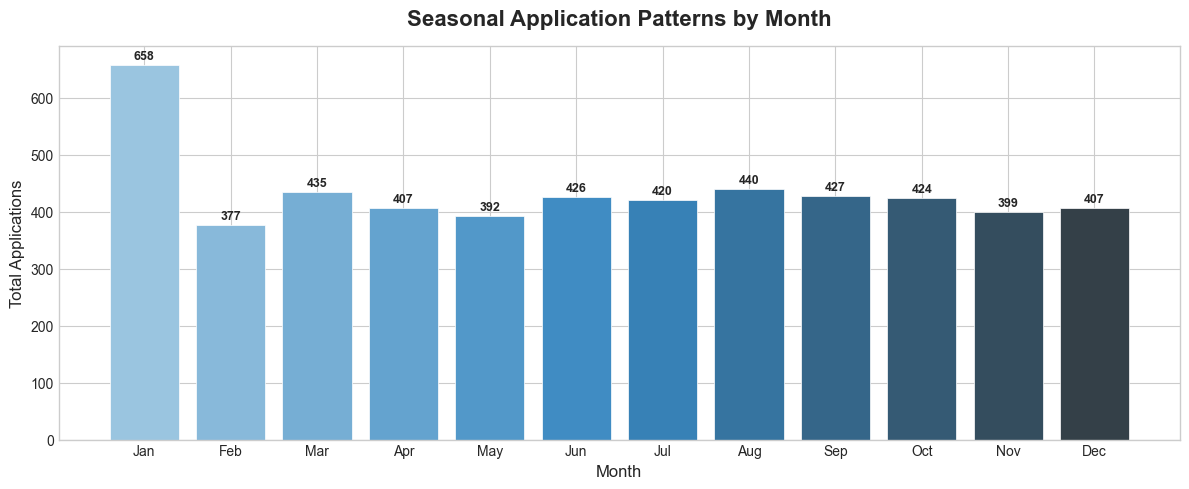

Saved: 02_seasonal_hiring_patterns.png


In [4]:
apps['month_name'] = apps['applied_at'].dt.strftime('%b')
apps['month_num'] = apps['applied_at'].dt.month
seasonal = apps.groupby(['month_num', 'month_name']).size().reset_index(name='applications')
seasonal = seasonal.sort_values('month_num')

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(seasonal['month_name'], seasonal['applications'],
              color=sns.color_palette("Blues_d", len(seasonal)),
              edgecolor='white', linewidth=0.5)

# Add value labels on bars
for bar, val in zip(bars, seasonal['applications']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Seasonal Application Patterns by Month', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Applications', fontsize=12)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../outputs/charts/02_seasonal_hiring_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_seasonal_hiring_patterns.png")

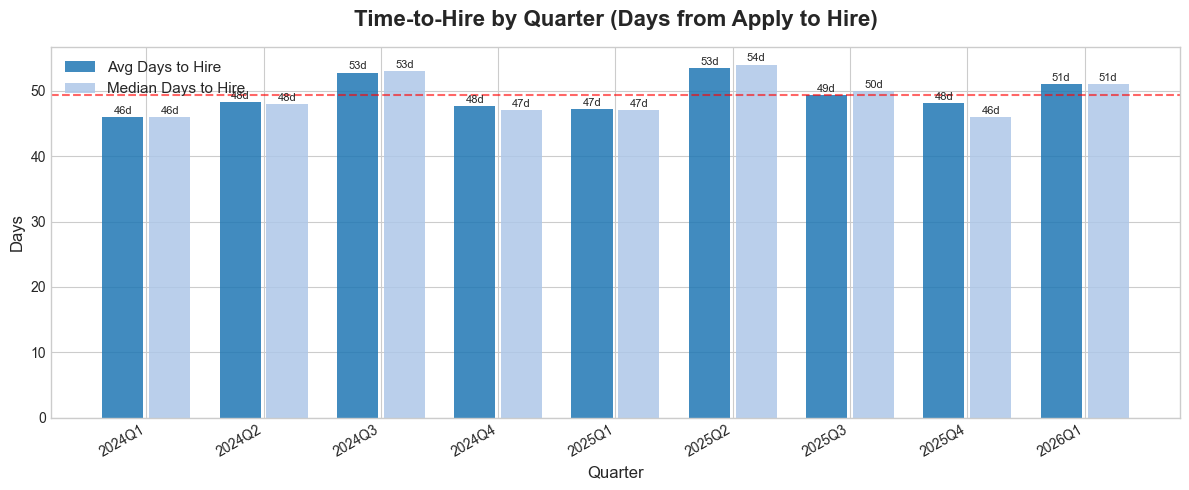

Overall avg time-to-hire: 49.5 days
Saved: 03_time_to_hire_by_quarter.png


In [5]:
# Merge applications and hires to calculate days from apply to hire
tth = apps[['application_id', 'applied_at']].merge(
    hires[['application_id', 'hired_at']], on='application_id', how='inner'
)
tth['days_to_hire'] = (tth['hired_at'] - tth['applied_at']).dt.days
tth['quarter'] = tth['hired_at'].dt.to_period('Q').astype(str)

quarterly_tth = tth.groupby('quarter')['days_to_hire'].agg(['mean', 'median']).reset_index()
quarterly_tth.columns = ['quarter', 'avg_days', 'median_days']

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(quarterly_tth))
ax.bar([i - 0.2 for i in x], quarterly_tth['avg_days'],
       width=0.35, label='Avg Days to Hire', color='#1f77b4', alpha=0.85)
ax.bar([i + 0.2 for i in x], quarterly_tth['median_days'],
       width=0.35, label='Median Days to Hire', color='#aec7e8', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(quarterly_tth['quarter'], rotation=30, ha='right')
ax.set_title('Time-to-Hire by Quarter (Days from Apply to Hire)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Quarter', fontsize=12)
ax.set_ylabel('Days', fontsize=12)
ax.legend(fontsize=11)
ax.axhline(y=quarterly_tth['avg_days'].mean(), color='red',
           linestyle='--', alpha=0.6, label='Overall Avg')

# Add value labels
for i, (avg, med) in enumerate(zip(quarterly_tth['avg_days'], quarterly_tth['median_days'])):
    ax.text(i - 0.2, avg + 0.5, f'{avg:.0f}d', ha='center', fontsize=8)
    ax.text(i + 0.2, med + 0.5, f'{med:.0f}d', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/charts/03_time_to_hire_by_quarter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Overall avg time-to-hire: {tth['days_to_hire'].mean():.1f} days")
print("Saved: 03_time_to_hire_by_quarter.png")

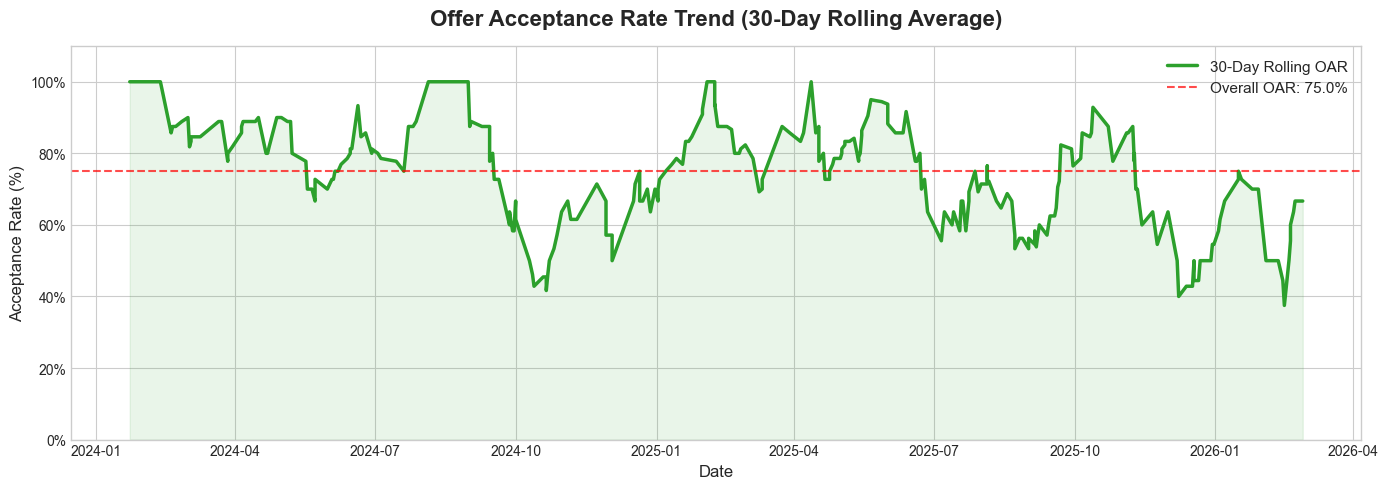

Overall Offer Acceptance Rate: 75.0%
Saved: 04_offer_acceptance_rate_trend.png


In [6]:
offers_sorted = offers.sort_values('offered_at').copy()
offers_sorted['accepted'] = (offers_sorted['offer_status'] == 'Accepted').astype(int)
offers_sorted = offers_sorted.set_index('offered_at')
rolling_oar = offers_sorted['accepted'].rolling('30D').mean().reset_index()
rolling_oar.columns = ['date', 'acceptance_rate']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rolling_oar['date'], rolling_oar['acceptance_rate'] * 100,
        color='#2ca02c', linewidth=2.5, label='30-Day Rolling OAR')
ax.fill_between(rolling_oar['date'], rolling_oar['acceptance_rate'] * 100,
                alpha=0.1, color='#2ca02c')
ax.axhline(y=offers_sorted['accepted'].mean() * 100, color='red',
           linestyle='--', alpha=0.7, label=f"Overall OAR: {offers_sorted['accepted'].mean()*100:.1f}%")

ax.set_title('Offer Acceptance Rate Trend (30-Day Rolling Average)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Acceptance Rate (%)', fontsize=12)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_ylim(0, 110)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/charts/04_offer_acceptance_rate_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Overall Offer Acceptance Rate: {offers_sorted['accepted'].mean()*100:.1f}%")
print("Saved: 04_offer_acceptance_rate_trend.png")

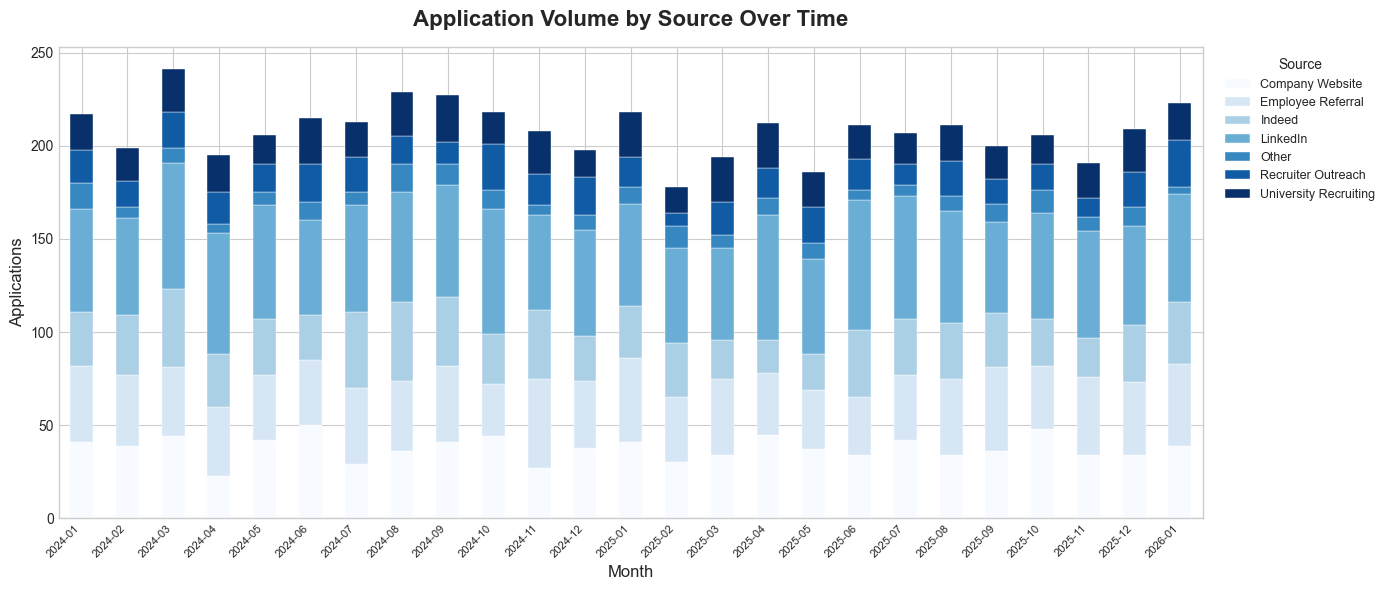

Saved: 05_application_source_mix.png
HIRING TRENDS — SUMMARY METRICS
Total Applications:        5,212
Total Hires:               210
Overall Conversion Rate:   4.0%
Avg Time-to-Hire:          49.5 days
Median Time-to-Hire:       49.0 days
Offer Acceptance Rate:     75.0%
Peak Application Month:    2024-03
Top Source:                LinkedIn


In [7]:
apps['year_month_str'] = apps['year_month'].astype(str)
source_monthly = apps.groupby(['year_month_str', 'source']).size().reset_index(name='count')
source_pivot = source_monthly.pivot(index='year_month_str', columns='source', values='count').fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
source_pivot.plot(kind='bar', stacked=True, ax=ax,
                  colormap='Blues', edgecolor='white', linewidth=0.3)
ax.set_title('Application Volume by Source Over Time', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Applications', fontsize=12)
ax.legend(title='Source', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/charts/05_application_source_mix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 05_application_source_mix.png")

# Cell 8 — Summary Metrics
print("=" * 50)
print("HIRING TRENDS — SUMMARY METRICS")
print("=" * 50)
print(f"Total Applications:        {len(apps):,}")
print(f"Total Hires:               {len(hires):,}")
print(f"Overall Conversion Rate:   {len(hires)/len(apps)*100:.1f}%")
print(f"Avg Time-to-Hire:          {tth['days_to_hire'].mean():.1f} days")
print(f"Median Time-to-Hire:       {tth['days_to_hire'].median():.1f} days")
print(f"Offer Acceptance Rate:     {offers_sorted['accepted'].mean()*100:.1f}%")
print(f"Peak Application Month:    {monthly.loc[peak_idx, 'year_month_str']}")
print(f"Top Source:                {apps['source'].value_counts().index[0]}")
print("=" * 50)

---

**Before running — create this folder in your repo:**

outputs/charts/